# Notebook 01 — Carga, EDA, limpieza y partición

**Proyecto final de Fundamentos de Inteligencia Artificial · Universidad EIA (2026-2)**

**Problema.** Queremos predecir si en el siguiente turno de trabajo (8 horas) de una mina de carbón va a haber un evento sísmico de alta energía (más de 10⁴ J), usando las mediciones del turno anterior. Es una clasificación binaria: `class = 1` es un turno peligroso y `class = 0` es uno sin peligro.

**Datos.** *seismic-bumps*, del repositorio de UCI (id 266). Son mediciones de dos tajos largos de una mina de carbón en Polonia.

**Fuente.** Sikora, M. y Wróbel, Ł. (2010). *Application of rule induction algorithms for analysis of data collected by seismic hazard monitoring systems in coal mines*. Archives of Mining Sciences, 55(1), 91-114.

**Qué hace este notebook.** Carga el archivo oficial `.arff`, explora las variables, limpia lo que haga falta, parte los datos en entrenamiento y prueba (80/20) y codifica las categóricas. Deja listos `data/train.csv`, `data/test.csv`, `data/test_original.csv` y `models/mapeos_categoricas.joblib`, que son lo que leen los notebooks siguientes y la app.

In [20]:
# Si corremos en Google Colab ponemos True; en el computador (VS Code), False
EN_COLAB = False

if EN_COLAB:
    # En Colab hay que instalar lo que no viene de fábrica, y se repite en cada sesión nueva
    !pip install phik shap gradio imbalanced-learn -q
    # En Colab los archivos viven en Drive, así que primero lo montamos
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/Proyecto_Sismos/'
else:
    RUTA_BASE = './'

# Todas las rutas del notebook salen de aquí, para no tener rutas regadas por el código
RUTA_DATOS = RUTA_BASE + 'data/'
RUTA_MODELOS = RUTA_BASE + 'models/'
RUTA_RESULTADOS = RUTA_BASE + 'resultados/'
RUTA_FIGURAS = RUTA_BASE + 'figuras/'

In [21]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
from sklearn.model_selection import train_test_split

import phik
from phik.report import plot_correlation_matrix

# Por si las carpetas de salida no existen (por ejemplo, en una carpeta nueva de Drive)
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)

## Cargar los datos

Vamos a leer el archivo oficial `seismic-bumps.arff` (el CSV que hay en `data/` es solo una copia de referencia y no lo usamos). El ARFF trae las columnas de texto como bytes (`b'a'`), así que armamos una función que lo lee y las deja como texto normal. La dejamos como función porque es una sola tarea bien definida y así queda clara para quien clone el repositorio.

In [22]:
def cargar_arff(ruta):
    """
    Lee el archivo .arff oficial de UCI y lo devuelve como DataFrame.
    Recibe la ruta del archivo. scipy entrega las columnas de texto como bytes (b'a'), así que aquí
    las pasamos a texto normal ('a') para poder trabajarlas igual que si vinieran de un CSV.
    """
    datos_arff, meta = arff.loadarff(ruta)
    df = pd.DataFrame(datos_arff)
    for columna in df.columns:
        # Solo las columnas de texto llegan como bytes; las numéricas ya vienen como float
        if df[columna].dtype == object:
            df[columna] = df[columna].str.decode('utf-8')
    return df

datos = cargar_arff(RUTA_DATOS + 'seismic-bumps.arff')
datos['class'] = datos['class'].astype(int)   # en el ARFF la clase viene como texto '0' / '1'
print('Filas y columnas:', datos.shape)
datos.head()

Filas y columnas: (2584, 19)


,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,a,a,N,15180.0,48.0,-72.0,-72.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,a,a,N,14720.0,33.0,-70.0,-79.0,a,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2000.0,2000.0,0
2,a,a,N,8050.0,30.0,-81.0,-78.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,a,a,N,28820.0,171.0,-23.0,40.0,a,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3000.0,3000.0,0
4,a,a,N,12640.0,57.0,-63.0,-52.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [23]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2584 entries, 0 to 2583
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   seismic         2584 non-null   str    
 1   seismoacoustic  2584 non-null   str    
 2   shift           2584 non-null   str    
 3   genergy         2584 non-null   float64
 4   gpuls           2584 non-null   float64
 5   gdenergy        2584 non-null   float64
 6   gdpuls          2584 non-null   float64
 7   ghazard         2584 non-null   str    
 8   nbumps          2584 non-null   float64
 9   nbumps2         2584 non-null   float64
 10  nbumps3         2584 non-null   float64
 11  nbumps4         2584 non-null   float64
 12  nbumps5         2584 non-null   float64
 13  nbumps6         2584 non-null   float64
 14  nbumps7         2584 non-null   float64
 15  nbumps89        2584 non-null   float64
 16  energy          2584 non-null   float64
 17  maxenergy       2584 non-null   float64
 18 

**Lo que notamos.** El archivo trae 2.584 filas y 19 columnas, justo lo que dice UCI: 18 variables de entrada más la columna `class`. Cuatro columnas son de texto (`seismic`, `seismoacoustic`, `shift` y `ghazard`) y el resto son numéricas. `info()` muestra que ninguna columna tiene datos faltantes.

## Revisión de variables

Antes de graficar queremos saber qué tipo de dato es cada columna, cuántos valores distintos tiene y si hay nulos. Armamos una función que junta eso en una tabla, porque la vamos a usar otra vez después de limpiar.

Un resumen de lo que mide cada variable, según la descripción de UCI: `seismic` y `ghazard` son evaluaciones del peligro del turno (por el método sísmico y por el sismoacústico, con letras de menos a más peligro) y `seismoacoustic` es otra evaluación sismoacústica; `shift` dice si el turno fue de extracción de carbón (W) o de preparación (N). `genergy` y `gpuls` son la energía y el número de pulsos del geófono más activo en el turno anterior, y `gdenergy` y `gdpuls` cuánto se desvían de lo normal de los ocho turnos previos. `nbumps` cuenta los golpes sísmicos del turno anterior y `nbumps2` a `nbumps89` los separan por rango de energía. `energy` y `maxenergy` son la energía total y la máxima de esos golpes.

In [24]:
def resumen_columnas(df):
    """
    Arma una tabla con una fila por columna: su tipo de dato, cuántos valores distintos tiene y
    cuántos nulos. Recibe un DataFrame y devuelve otro DataFrame con el resumen. Nos sirve para ver
    de un vistazo qué columnas son categóricas, cuáles casi no cambian y si falta algún dato.
    """
    filas = []
    for columna in df.columns:
        filas.append({
            'Columna': columna,
            'Tipo': str(df[columna].dtype),
            'Valores_distintos': df[columna].nunique(),
            'Nulos': df[columna].isna().sum(),
        })
    return pd.DataFrame(filas)

resumen_columnas(datos)

,Columna,Tipo,Valores_distintos,Nulos
0,seismic,str,2,0
1,seismoacoustic,str,3,0
2,shift,str,2,0
3,genergy,float64,2212,0
4,gpuls,float64,1128,0
5,gdenergy,float64,334,0
6,gdpuls,float64,292,0
7,ghazard,str,3,0
8,nbumps,float64,10,0
9,nbumps2,float64,7,0


In [25]:
datos.describe()

,genergy,gpuls,gdenergy,gdpuls,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
count,2.584000e+03,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.0,2584.0,2584.0,2584.000000,2584.000000,2584.000000
mean,9.024252e+04,538.579334,12.375774,4.508901,0.859520,0.393576,0.392802,0.067724,0.004644,0.0,0.0,0.0,4975.270898,4278.850619,0.065789
std,2.292005e+05,562.652536,80.319051,63.166556,1.364616,0.783772,0.769710,0.279059,0.068001,0.0,0.0,0.0,20450.833222,19357.454882,0.247962
min,1.000000e+02,2.000000,-96.000000,-96.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
25%,1.166000e+04,190.000000,-37.000000,-36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
50%,2.548500e+04,379.000000,-6.000000,-6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
75%,5.283250e+04,669.000000,38.000000,30.250000,1.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.0,0.0,2600.000000,2000.000000,0.000000
max,2.595650e+06,4518.000000,1245.000000,838.000000,9.000000,8.000000,7.000000,3.000000,1.000000,0.0,0.0,0.0,402000.000000,400000.000000,1.000000


**Lo que notamos.** No hay nulos en ninguna columna. Las categóricas son `seismic` (2 valores distintos), `seismoacoustic` (3), `shift` (2) y `ghazard` (3); las otras 14 variables son numéricas. Tres de ellas, `nbumps6`, `nbumps7` y `nbumps89`, tienen un solo valor distinto y en `describe()` su máximo es 0, o sea que valen cero en todos los turnos.

También vemos que las variables de energía son muy desparejas. `genergy` tiene una media de unos 90.242 pero una mediana de 25.485 y un máximo de 2.595.650. En `energy` y `maxenergy` pasa algo parecido: la mediana es 0, el percentil 75 es 2.600 y 2.000, y los máximos llegan a 402.000 y 400.000. Es decir, en la mayoría de los turnos casi no hay golpes sísmicos y en unos pocos hay muchos.

## Distribución de la clase

Ahora vemos cuántos turnos peligrosos hay frente a los que no. Lo hacemos con `value_counts()` y una torta con porcentajes, como en clase, y además calculamos cuánto acertaría un "modelo" que siempre diga que no hay peligro.

class
0    2414
1     170
Name: count, dtype: int64


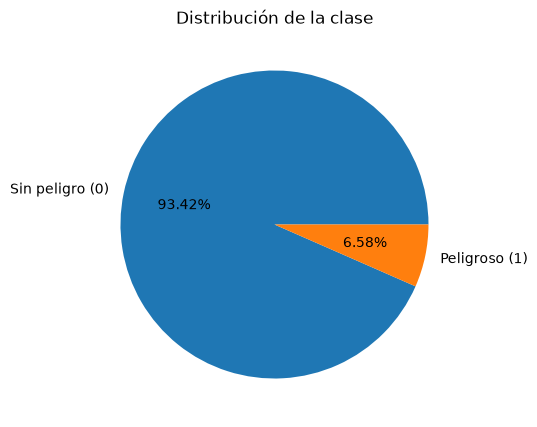

Accuracy de un modelo que siempre dice "sin peligro": 0.9342


In [26]:
conteo_clases = datos['class'].value_counts().sort_index()   # sort_index deja primero la clase 0
print(conteo_clases)

plt.figure(figsize=(5, 5))
plt.pie(conteo_clases, labels=['Sin peligro (0)', 'Peligroso (1)'], autopct='%.2f%%')
plt.title('Distribución de la clase')
plt.savefig(RUTA_FIGURAS + '01_distribucion_clase.png', bbox_inches='tight', dpi=150)
plt.show()

# Si el modelo siempre responde 0, acierta en todos los turnos que de verdad son 0
accuracy_siempre_cero = conteo_clases[0] / len(datos)
print('Accuracy de un modelo que siempre dice "sin peligro":', round(accuracy_siempre_cero, 4))

**Lo que notamos.** De los 2.584 turnos, 2.414 no tienen peligro y solo 170 sí, o sea 93,42% contra 6,58%. Un "modelo" que siempre responda que no hay peligro acierta el 93,42% de las veces y no detecta ni un solo turno peligroso. Por eso el accuracy no nos sirve para decidir nada en este proyecto.

La métrica principal va a ser el **F1 de la clase peligrosa**, que combina el recall (cuántos turnos peligrosos alcanzamos a detectar) con la precisión (cuántas de nuestras alertas son ciertas). El accuracy lo vamos a reportar, pero solo como referencia.

## Variables categóricas

Tenemos cuatro categóricas: `seismic`, `seismoacoustic`, `shift` y `ghazard`. Para cada una queremos ver dos cosas lado a lado: cuántos turnos hay en cada categoría y qué porcentaje de ellos fue peligroso. La segunda gráfica es la que nos dice si una categoría trae más riesgo. Lo hacemos función porque es exactamente la misma gráfica para las cuatro.

seismic -> {'a': 1682, 'b': 902}


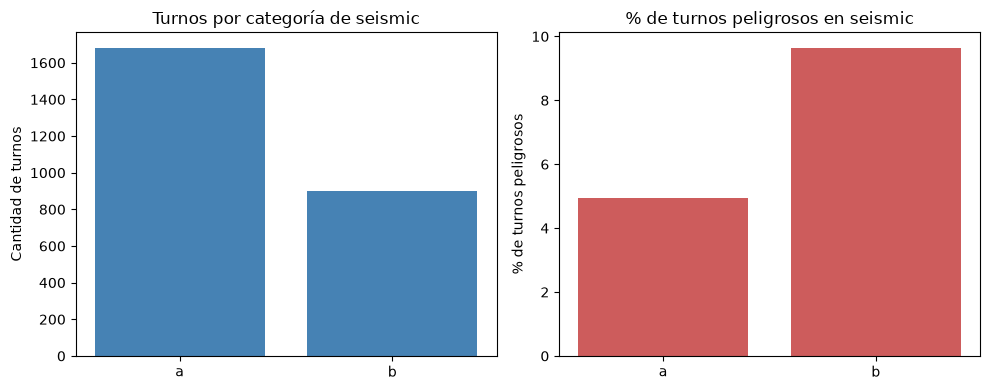

seismoacoustic -> {'a': 1580, 'b': 956, 'c': 48}


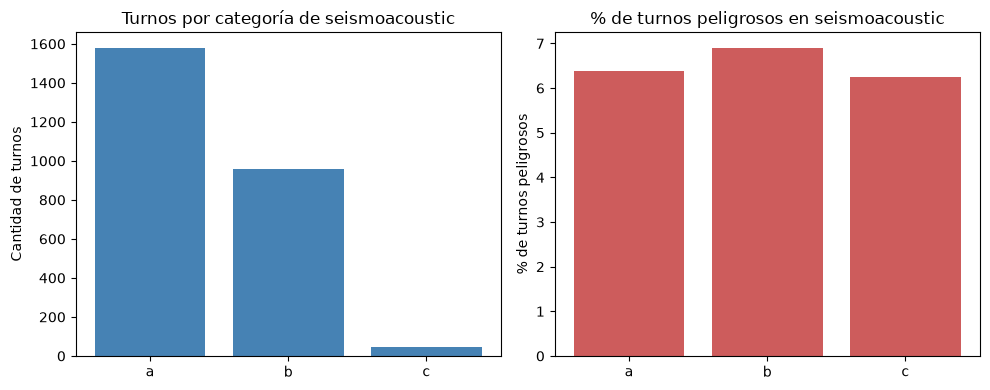

shift -> {'N': 921, 'W': 1663}


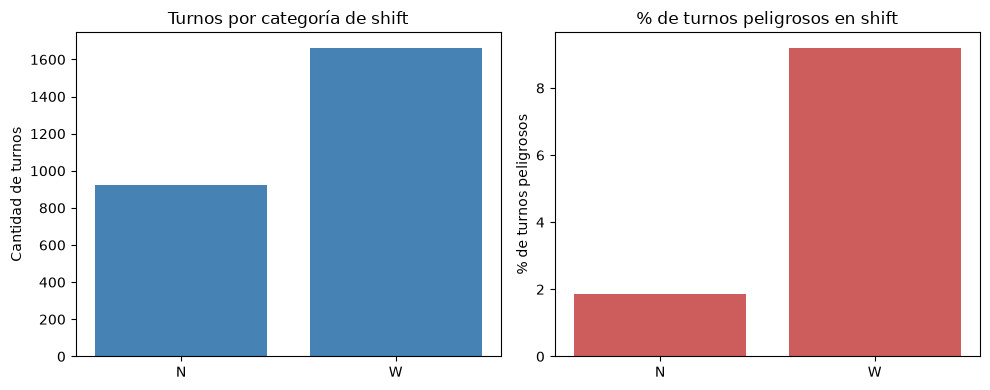

ghazard -> {'a': 2342, 'b': 212, 'c': 30}


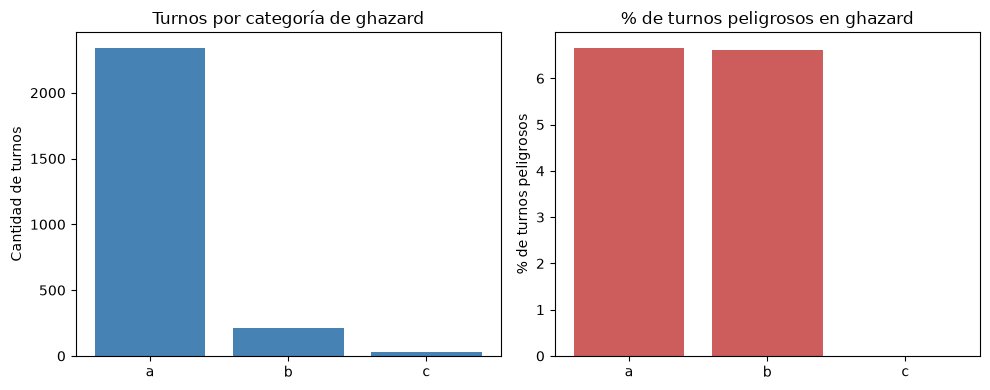

In [27]:
def graficar_categorica(df, columna, nombre_archivo):
    """
    Dibuja dos gráficas lado a lado para una columna categórica: el conteo de turnos por categoría y el
    porcentaje de turnos peligrosos (class = 1) dentro de cada categoría. Recibe el DataFrame, el nombre
    de la columna y la ruta donde guardar la imagen. No devuelve nada: guarda la figura y la muestra.
    Mirar el porcentaje, y no solo el conteo, es lo que deja ver si una categoría es más riesgosa.
    """
    conteo = df[columna].value_counts().sort_index()
    porcentaje_peligroso = pd.crosstab(df[columna], df['class'], normalize='index')[1] * 100

    fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
    ejes[0].bar(conteo.index.astype(str), conteo.values, color='steelblue')
    ejes[0].set_title('Turnos por categoría de ' + columna)
    ejes[0].set_ylabel('Cantidad de turnos')

    ejes[1].bar(porcentaje_peligroso.index.astype(str), porcentaje_peligroso.values, color='indianred')
    ejes[1].set_title('% de turnos peligrosos en ' + columna)
    ejes[1].set_ylabel('% de turnos peligrosos')

    plt.tight_layout()
    plt.savefig(nombre_archivo, bbox_inches='tight', dpi=150)
    plt.show()

columnas_categoricas = ['seismic', 'seismoacoustic', 'shift', 'ghazard']

for columna in columnas_categoricas:
    print(columna, '->', datos[columna].value_counts().sort_index().to_dict())
    graficar_categorica(datos, columna, RUTA_FIGURAS + '01_categorica_' + columna + '.png')

In [28]:
# Los porcentajes exactos de turnos peligrosos por categoría, para citarlos en las conclusiones
filas = []
for columna in columnas_categoricas:
    porcentajes = pd.crosstab(datos[columna], datos['class'], normalize='index')[1] * 100
    for categoria in porcentajes.index:
        filas.append({'Variable': columna, 'Categoria': categoria, 'Pct_peligrosos': round(porcentajes[categoria], 2)})
pd.DataFrame(filas)

,Variable,Categoria,Pct_peligrosos
0,seismic,a,4.93
1,seismic,b,9.65
2,seismoacoustic,a,6.39
3,seismoacoustic,b,6.90
4,seismoacoustic,c,6.25
5,shift,N,1.85
6,shift,W,9.20
7,ghazard,a,6.66
8,ghazard,b,6.60
9,ghazard,c,0.00


**Lo que notamos.** El porcentaje general de turnos peligrosos es de 6,58%, y lo usamos para comparar. El `shift` es lo que más se separa: en los turnos de extracción (W, 1.663 turnos) el 9,20% fue peligroso, mientras que en los de preparación (N, 921 turnos) solo el 1,85%. Parece lógico, porque cuando se extrae carbón hay más actividad en la mina. En `seismic` la categoría b tiene 9,65% de turnos peligrosos y la a 4,93%, así que también aporta algo.

En cambio `seismoacoustic` casi no distingue (6,39% en a, 6,90% en b y 6,25% en c) y `ghazard` tampoco: 6,66% en a y 6,60% en b. Su categoría c tiene 0% de peligrosos, pero son solo 30 turnos, así que no le damos mucho peso. Sospechamos que estas dos variables aportarán poco.

## Variables numéricas

Las numéricas son todas las que no son categóricas ni la clase. Armamos la lista con un ciclo y miramos primero qué tan asimétricas son (sobre todo las de energía), después los histogramas y por último un box plot de cada una separado por clase, para ver si los turnos peligrosos se comportan distinto.

In [29]:
columnas_numericas = []
for columna in datos.columns:
    if columna not in columnas_categoricas and columna != 'class':
        columnas_numericas.append(columna)
print(len(columnas_numericas), 'numéricas:', columnas_numericas)

# Asimetría y qué tan lejos queda el máximo del resto de los datos (percentil 75)
filas = []
for columna in columnas_numericas:
    filas.append({
        'Variable': columna,
        'Asimetria': round(datos[columna].skew(), 2),
        'Mediana': datos[columna].median(),
        'Percentil_75': datos[columna].quantile(0.75),
        'Maximo': datos[columna].max(),
    })
pd.DataFrame(filas)

14 numéricas: ['genergy', 'gpuls', 'gdenergy', 'gdpuls', 'nbumps', 'nbumps2', 'nbumps3', 'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy', 'maxenergy']


,Variable,Asimetria,Mediana,Percentil_75,Maximo
0,genergy,5.17,25485.0,52832.50,2595650.0
1,gpuls,2.48,379.0,669.00,4518.0
2,gdenergy,3.41,-6.0,38.00,1245.0
3,gdpuls,2.56,-6.0,30.25,838.0
4,nbumps,2.23,0.0,1.00,9.0
5,nbumps2,2.60,0.0,1.00,8.0
6,nbumps3,2.58,0.0,1.00,7.0
7,nbumps4,4.62,0.0,0.00,3.0
8,nbumps5,14.58,0.0,0.00,1.0
9,nbumps6,0.00,0.0,0.00,0.0


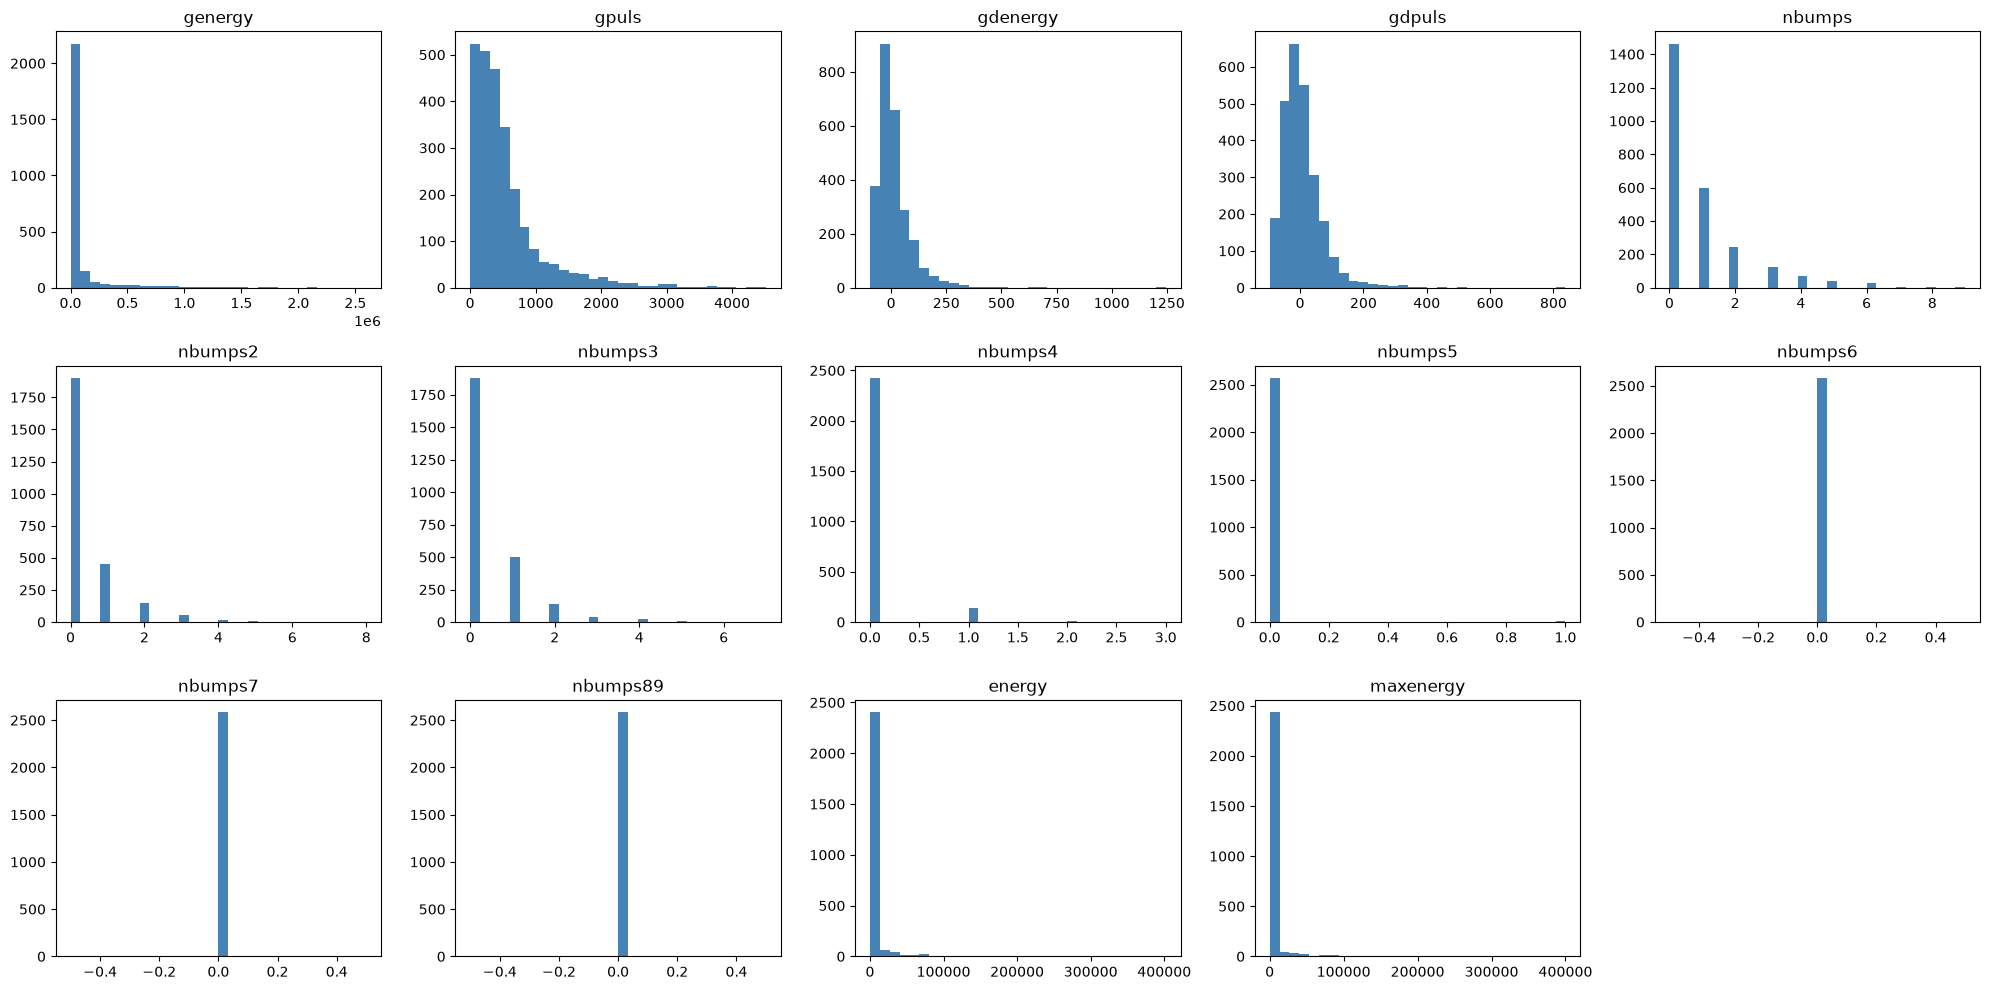

In [30]:
fig, ejes = plt.subplots(3, 5, figsize=(20, 10))
ejes = ejes.flatten()
for i, columna in enumerate(columnas_numericas):
    ejes[i].hist(datos[columna], bins=30, color='steelblue')
    ejes[i].set_title(columna)
# Son 14 numéricas y la cuadrícula tiene 15 espacios: apagamos el que sobra
for j in range(len(columnas_numericas), len(ejes)):
    ejes[j].axis('off')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '01_histogramas_numericas.png', bbox_inches='tight', dpi=150)
plt.show()

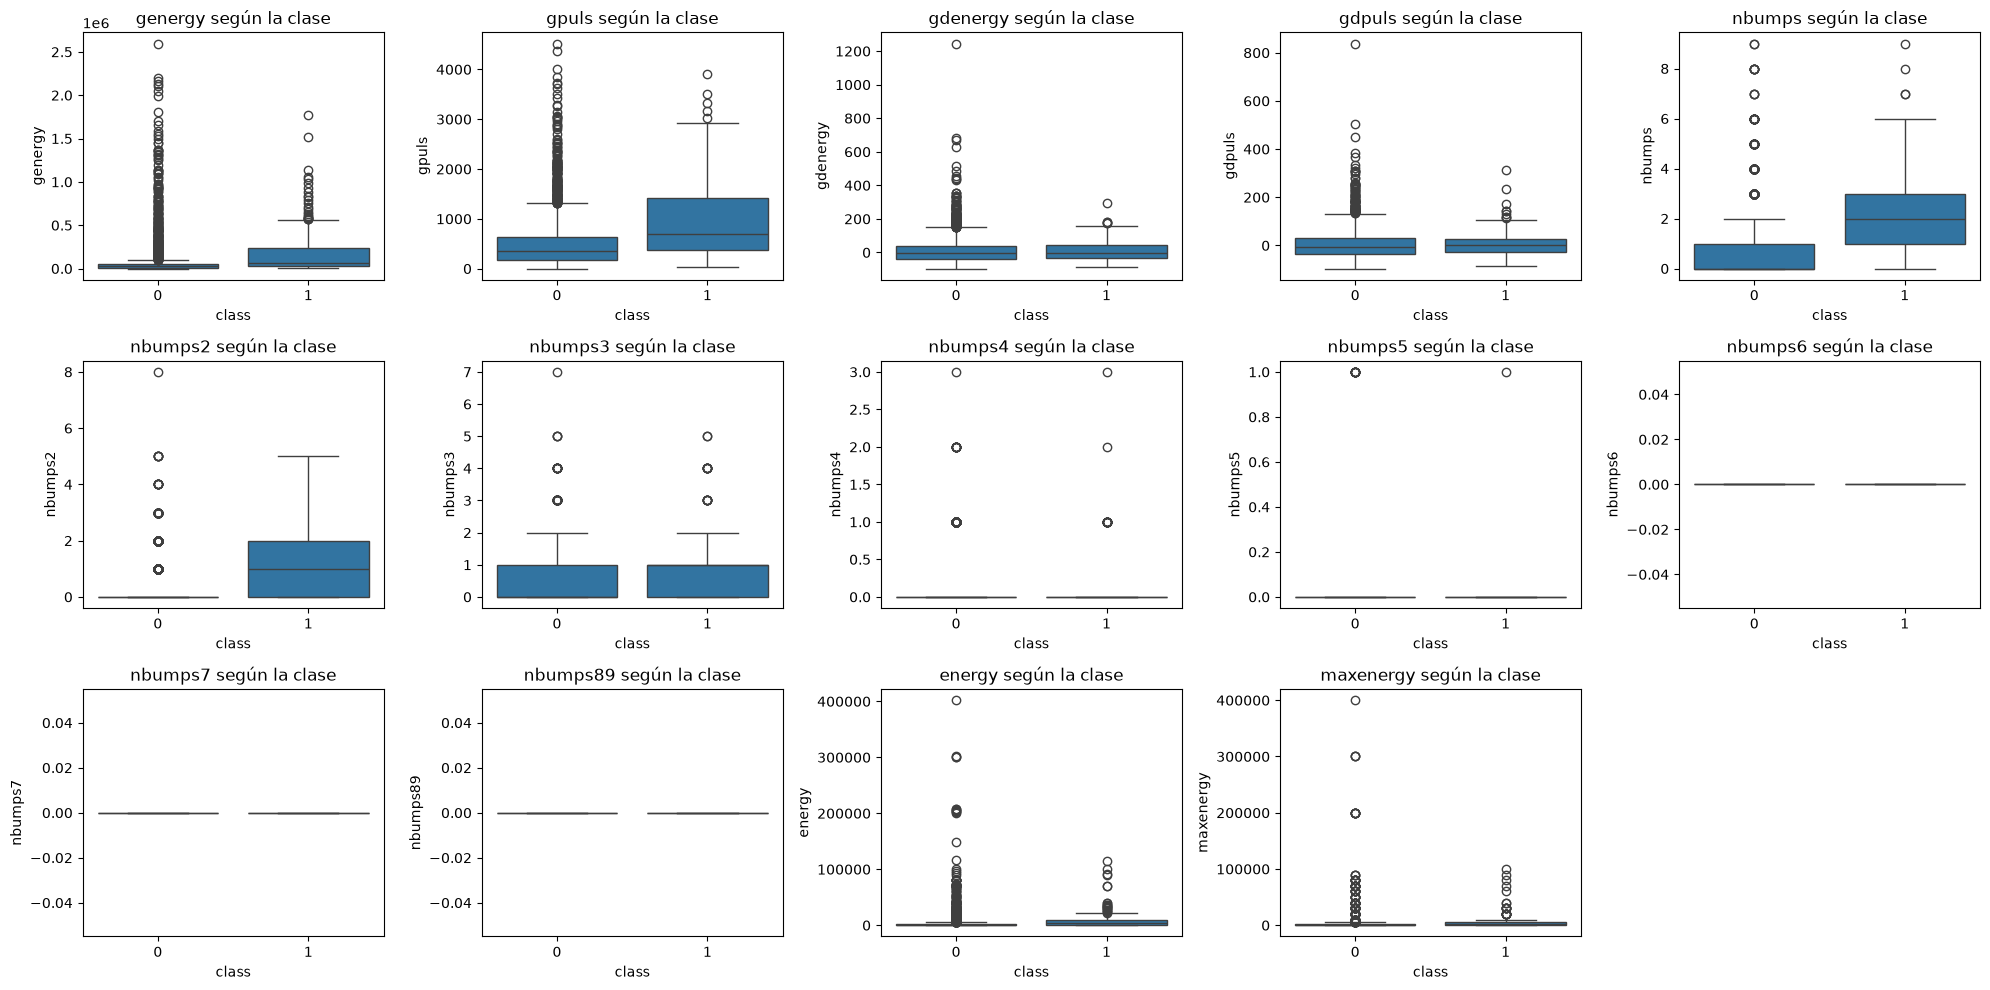

In [31]:
fig, ejes = plt.subplots(3, 5, figsize=(20, 10))
ejes = ejes.flatten()
for i, columna in enumerate(columnas_numericas):
    sns.boxplot(x='class', y=columna, data=datos, ax=ejes[i])
    ejes[i].set_title(columna + ' según la clase')
for j in range(len(columnas_numericas), len(ejes)):
    ejes[j].axis('off')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '01_boxplots_por_clase.png', bbox_inches='tight', dpi=150)
plt.show()

**Lo que notamos.** Todas las variables de energía y de conteo de golpes son muy asimétricas hacia la derecha: la asimetría de `genergy` es 5,17, la de `energy` 9,94, la de `maxenergy` 11,04 y la de `nbumps5` llega a 14,58. En los histogramas casi todos los turnos se juntan cerca de cero y unos pocos se estiran hacia valores enormes.

En los box plots por clase, los turnos peligrosos se ven más arriba en `nbumps` (la mediana de la clase 1 queda cerca de 2 y la de la clase 0 en 0), en `nbumps2`, en `gpuls` y en `genergy`. En `gdenergy` y `gdpuls` las cajas de las dos clases casi se superponen, así que ahí no hay mucha diferencia. Los box plots de `nbumps6`, `nbumps7` y `nbumps89` son líneas planas porque esas columnas son constantes.

**Decisión: no eliminamos los valores extremos.** Los puntos que se ven lejos en los box plots son eventos sísmicos reales, y detectar los eventos fuertes es justo el objetivo del proyecto. Quitarlos sería borrar la señal que queremos aprender. Más adelante, el escalado y los modelos tendrán que lidiar con ellos.

## Limpieza

Hacemos dos cosas. Primero contamos los duplicados (filas idénticas en todas las columnas) y miramos de qué clase son antes de quitarlos. Segundo, buscamos las columnas constantes con una función. Una columna que vale lo mismo en todas las filas no le sirve a ningún modelo, porque no distingue un turno de otro.

Los valores extremos **no los tocamos**: las energías muy altas son eventos sísmicos reales, y son justo lo que queremos aprender a detectar.

In [32]:
def columnas_constantes(df):
    """
    Devuelve la lista de columnas que tienen un solo valor en todas las filas.
    Recibe un DataFrame. Las buscamos porque una columna que nunca cambia no aporta información
    para separar turnos peligrosos de los que no lo son, y solo estorba en el modelo.
    """
    constantes = []
    for columna in df.columns:
        if df[columna].nunique() == 1:
            constantes.append(columna)
    return constantes

filas_antes = len(datos)
columnas_antes = datos.shape[1]

# Duplicados: contamos y miramos la clase antes de decidir
cantidad_duplicados = datos.duplicated().sum()
print('Filas duplicadas:', cantidad_duplicados)
print('Clase de las filas duplicadas:')
print(datos[datos.duplicated()]['class'].value_counts())

Filas duplicadas: 6
Clase de las filas duplicadas:
class
0    6
Name: count, dtype: int64


In [33]:
datos = datos.drop_duplicates().reset_index(drop=True)
print('Filas antes:', filas_antes, '| filas después:', len(datos))

# Columnas constantes
constantes = columnas_constantes(datos)
print('Columnas constantes:', constantes)
datos = datos.drop(columns=constantes)
for columna in constantes:
    columnas_numericas.remove(columna)   # ya no existen, las sacamos también de la lista de numéricas

print('Forma final:', datos.shape)
resumen_columnas(datos)

Filas antes: 2584 | filas después: 2578
Columnas constantes: ['nbumps6', 'nbumps7', 'nbumps89']
Forma final: (2578, 16)


,Columna,Tipo,Valores_distintos,Nulos
0,seismic,str,2,0
1,seismoacoustic,str,3,0
2,shift,str,2,0
3,genergy,float64,2212,0
4,gpuls,float64,1128,0
5,gdenergy,float64,334,0
6,gdpuls,float64,292,0
7,ghazard,str,3,0
8,nbumps,float64,10,0
9,nbumps2,float64,7,0


**Lo que notamos.** Había 6 filas duplicadas y las 6 eran de clase 0, así que quitarlas no nos cuesta ningún turno peligroso: pasamos de 2.584 a 2.578 filas y los 170 turnos de clase 1 se conservan. Las columnas constantes fueron exactamente las tres que esperábamos: `nbumps6`, `nbumps7` y `nbumps89`. Las eliminamos porque valen cero en todos los turnos y no pueden ayudar a separar nada.

Después de la limpieza quedan 2.578 filas y 16 columnas: 15 variables de entrada más `class`. Con el resumen de columnas confirmamos que siguen sin nulos.

## Correlación con phik

Como en clase, usamos **phik**, que calcula una correlación que sirve para categóricas y numéricas al mismo tiempo (la correlación de Pearson no sirve con letras). Le decimos cuáles son numéricas con `interval_cols`; el resto las trata como categorías. Queremos ver qué variables se relacionan más con `class` y cuáles son redundantes entre sí.

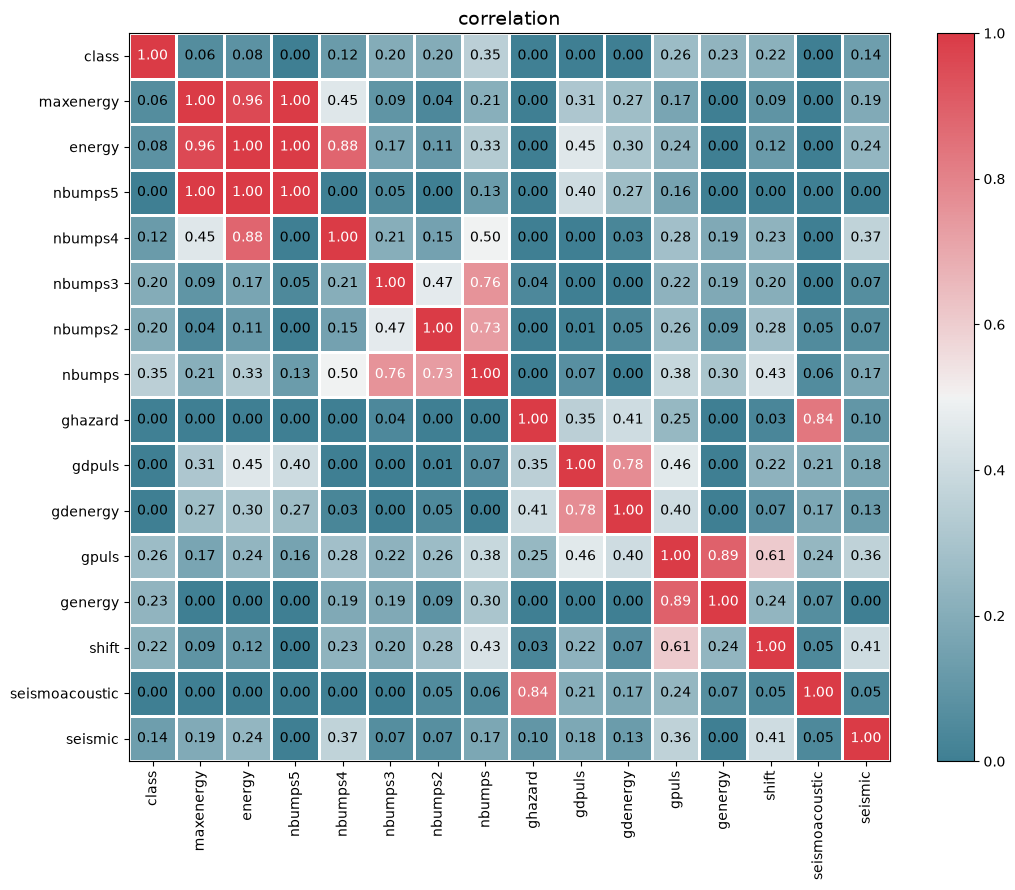

nbumps            0.350
gpuls             0.263
genergy           0.231
shift             0.216
nbumps3           0.196
nbumps2           0.196
seismic           0.135
nbumps4           0.122
energy            0.083
maxenergy         0.061
ghazard           0.005
gdpuls            0.000
gdenergy          0.000
seismoacoustic    0.000
nbumps5           0.000
Name: class, dtype: float64

In [34]:
matriz_phik = datos.phik_matrix(interval_cols=columnas_numericas)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

plot_correlation_matrix(matriz_phik.values, x_labels=matriz_phik.columns, y_labels=matriz_phik.index,
                        vmin=0, vmax=1, color_map=cmap, figsize=(11, 9))
plt.savefig(RUTA_FIGURAS + '01_correlacion_phik.png', bbox_inches='tight', dpi=150)
plt.show()

# Qué tanto se relaciona cada variable con la clase, de mayor a menor
correlacion_con_clase = matriz_phik['class'].drop('class').sort_values(ascending=False)
correlacion_con_clase.round(3)

In [35]:
# Parejas de variables muy parecidas entre sí (posible redundancia). El 0.8 lo elegimos nosotros como "muy alta"
nombres = list(matriz_phik.columns)
parejas = []
for i in range(len(nombres)):
    for j in range(i + 1, len(nombres)):
        valor = matriz_phik.iloc[i, j]
        if valor >= 0.8 and 'class' not in (nombres[i], nombres[j]):
            parejas.append({'Variable_1': nombres[i], 'Variable_2': nombres[j], 'phik': round(valor, 2)})
pd.DataFrame(parejas, columns=['Variable_1', 'Variable_2', 'phik']).sort_values('phik', ascending=False)

,Variable_1,Variable_2,phik
4,nbumps5,maxenergy,1.00
3,nbumps5,energy,1.00
5,energy,maxenergy,0.96
1,genergy,gpuls,0.89
2,nbumps4,energy,0.88
0,seismoacoustic,ghazard,0.84


**Lo que notamos.** Ninguna variable se relaciona fuerte con la clase. La más alta es `nbumps` con 0,350, seguida de `gpuls` (0,263), `genergy` (0,231), `shift` (0,216), `nbumps3` y `nbumps2` (0,196 cada una), `seismic` (0,135) y `nbumps4` (0,122). `energy` (0,083), `maxenergy` (0,061) y `ghazard` (0,005) casi no aportan, y `gdpuls`, `gdenergy`, `seismoacoustic` y `nbumps5` quedan en 0,000. Esto cuadra con lo que vimos en los gráficos y avisa que el problema va a ser difícil: no hay una variable que por sí sola distinga bien los turnos peligrosos.

También hay variables redundantes entre sí. `energy` y `maxenergy` tienen un phik de 0,96, `genergy` y `gpuls` de 0,89, `nbumps4` y `energy` de 0,88, y `seismoacoustic` y `ghazard` de 0,84, lo que tiene sentido porque ambas evalúan el peligro con el método sismoacústico. `nbumps5` aparece con 1,00 respecto a `energy` y `maxenergy`, pero `nbumps5` casi nunca cambia (su media es 0,0046, o sea que apenas hay un puñado de turnos con valor 1), así que ese número hay que tomarlo con cuidado. No quitamos ninguna variable por esto todavía: la selección de rasgos se decide en el notebook 02, solo con los datos de entrenamiento.

## Partición 80/20

Separamos el 80% para entrenar y el 20% para la prueba final. Lo hacemos **una sola vez, aquí, y antes de codificar**, para poder guardar una copia de test con las letras originales (la usa la app). Usamos `stratify=y` para que train y test queden con casi el mismo porcentaje de turnos peligrosos; sin eso, con tan pocos positivos, podríamos quedarnos con muy pocos en test por mala suerte. Desde este punto **no volvemos a mirar test** para decidir nada: solo lo guardamos y lo usamos al final, en el notebook 04.

In [36]:
X = datos.drop(columns=['class'])
y = datos['class']

# stratify=y para que train y test queden con el mismo ~6,6% de turnos peligrosos
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Solo verificamos que la proporción de la clase quedó pareja; no miramos nada más de test
rows = []
for nombre, etiquetas in [('Completo', y), ('Train', y_train), ('Test', y_test)]:
    rows.append({
        'Conjunto': nombre,
        'Filas': len(etiquetas),
        'Peligrosos': int(etiquetas.sum()),
        'Pct_peligrosos': round(etiquetas.mean() * 100, 2),
    })
pd.DataFrame(rows)

,Conjunto,Filas,Peligrosos,Pct_peligrosos
0,Completo,2578,170,6.59
1,Train,2062,136,6.60
2,Test,516,34,6.59


**Lo que notamos.** La partición quedó con 2.062 turnos en train (136 peligrosos, 6,60%) y 516 en test (34 peligrosos, 6,59%). El conjunto completo tiene 6,59%, así que la estratificación funcionó y los dos conjuntos mantienen casi la misma proporción. Con solo 34 turnos peligrosos en test, cada acierto o error va a mover mucho las métricas finales; lo tendremos presente en el notebook 04.

## Codificación ordinal

Los modelos necesitan números, no letras. Usamos un diccionario fijo (`mapeos`) para pasar cada letra a un número. Lo guardamos para que los notebooks y la app usen exactamente los mismos valores. Como las evaluaciones de peligro van de menos a más (a < b < c < d), una codificación ordinal respeta ese orden; con one-hot lo perderíamos y además crearíamos más columnas. Tampoco usamos `LabelEncoder`: en clase se usó para la etiqueta, y aquí la etiqueta ya es 0/1.

Dejamos la 'd' en el diccionario aunque no aparezca en los datos, por si la app recibe algún día un turno con esa evaluación.

In [37]:
# Las evaluaciones de peligro van de menos a más (a = sin peligro, b = bajo, c = alto, d = estado de peligro),
# así que números ordenados conservan ese orden. Dejamos la 'd' aunque no aparezca en los datos,
# por si la app recibe un turno con esa evaluación.
mapeos = {
    'seismic': {'a': 0, 'b': 1, 'c': 2, 'd': 3},
    'seismoacoustic': {'a': 0, 'b': 1, 'c': 2, 'd': 3},
    'ghazard': {'a': 0, 'b': 1, 'c': 2, 'd': 3},
    'shift': {'N': 0, 'W': 1},   # N = turno de preparación, W = turno de extracción de carbón
}

def codificar_categoricas(df, mapeos):
    """
    Cambia las letras de las columnas categóricas por números usando el diccionario `mapeos`.
    Recibe un DataFrame con las columnas originales (por ejemplo seismic = 'a' o 'b') y devuelve
    una copia con esas columnas ya numéricas. No modifica el DataFrame que recibe.
    """
    df_codificado = df.copy()
    for columna in mapeos:
        # Si la columna no está (por ejemplo, porque la quitamos en la selección de rasgos), la saltamos
        if columna in df_codificado.columns:
            # Usamos el mismo diccionario en los notebooks y en la app, así una 'b' siempre vale 1
            df_codificado[columna] = df_codificado[columna].map(mapeos[columna])
    return df_codificado

X_train = codificar_categoricas(X_train_original, mapeos)
X_test = codificar_categoricas(X_test_original, mapeos)

# Si quedara algún nulo, habría una letra que no está en mapeos
print('Nulos en train:', X_train.isna().sum().sum(), '| nulos en test:', X_test.isna().sum().sum())
X_train.head()

Nulos en train: 0 | nulos en test: 0


,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,energy,maxenergy
817,0,0,0,850.0,6.0,-85.0,-90.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2295,1,1,1,12850.0,193.0,-51.0,-60.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1677,0,1,1,65790.0,822.0,107.0,64.0,0,1.0,0.0,1.0,0.0,0.0,7000.0,7000.0
1887,0,0,1,32620.0,718.0,0.0,17.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1602,0,0,0,8460.0,252.0,-18.0,-28.0,0,1.0,1.0,0.0,0.0,0.0,200.0,200.0


**Lo que notamos.** Después de aplicar el diccionario no quedó ningún nulo ni en train ni en test, o sea que todas las letras estaban en `mapeos`. Las cuatro categóricas ya son números: por ejemplo, un turno de extracción (`shift = 'W'`) ahora vale 1 y uno de preparación vale 0.

## Guardar

Guardamos lo que necesitan los demás notebooks y la app: `train.csv` y `test.csv` con los rasgos ya codificados más la columna `class`, `test_original.csv` con las letras originales (para que la app muestre turnos reales) y el diccionario `mapeos` en `models/`.

In [38]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)
test_original = pd.concat([X_test_original, y_test], axis=1)

train.to_csv(RUTA_DATOS + 'train.csv', index=False)
test.to_csv(RUTA_DATOS + 'test.csv', index=False)
test_original.to_csv(RUTA_DATOS + 'test_original.csv', index=False)
joblib.dump(mapeos, RUTA_MODELOS + 'mapeos_categoricas.joblib')

# Comprobamos que los cuatro archivos quedaron escritos
for ruta in [RUTA_DATOS + 'train.csv', RUTA_DATOS + 'test.csv', RUTA_DATOS + 'test_original.csv',
             RUTA_MODELOS + 'mapeos_categoricas.joblib']:
    print(ruta, '->', os.path.getsize(ruta), 'bytes')
print('Columnas de train:', list(train.columns))

./data/train.csv -> 137204 bytes
./data/test.csv -> 34251 bytes
./data/test_original.csv -> 34251 bytes
./models/mapeos_categoricas.joblib -> 145 bytes
Columnas de train: ['seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls', 'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3', 'nbumps4', 'nbumps5', 'energy', 'maxenergy', 'class']


## Conclusiones

- **Datos.** El ARFF oficial tiene 2.584 filas y 19 columnas, sin nulos, como dice UCI. Después de la limpieza quedaron 2.578 filas y 16 columnas.
- **Limpieza.** Quitamos 6 duplicados (todos de clase 0) y 3 columnas constantes (`nbumps6`, `nbumps7` y `nbumps89`). No eliminamos valores extremos porque son eventos sísmicos reales, que es lo que queremos detectar.
- **Desbalance.** Solo 170 turnos son peligrosos, el 6,58% de los datos. Un modelo que siempre diga "sin peligro" acierta el 93,42%, así que el accuracy no sirve y trabajamos con el F1 de la clase peligrosa.
- **Qué se relaciona con la clase.** Según phik, lo más relacionado es `nbumps` (0,350), `gpuls` (0,263), `genergy` (0,231) y `shift` (0,216), y los turnos de extracción (W) son mucho más peligrosos (9,20%) que los de preparación (1,85%). Aun así ninguna relación es fuerte, y esperamos que el problema sea difícil. Además hay variables muy redundantes entre sí, como `energy` y `maxenergy` (0,96), algo que revisaremos en la selección de rasgos.
- **Partición.** Train tiene 2.062 turnos (136 peligrosos) y test tiene 516 (34 peligrosos), ambos con alrededor de 6,6% de turnos peligrosos. Test queda guardado sin tocar hasta el notebook 04.
- **Archivos generados.** `data/train.csv`, `data/test.csv`, `data/test_original.csv` y `models/mapeos_categoricas.joblib`, además de las figuras en `figuras/`.

**Siguiente paso:** el notebook 02, donde con `train.csv` decidimos qué escalador usar y con qué rasgos nos quedamos.